# APS EDA with Seaborn



In [4]:
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.max_columns', 20)

root = Path.cwd()
if not (root / 'data').exists():
    root = root.parent

raw_dir = root / 'data' / 'raw'
fig_dir = root / 'thesis_doc' / 'figures'
raw_dir


WindowsPath('c:/Users/user/Downloads/BSc_Theisis/data/raw')

In [5]:
def load_aps(path: Path) -> pd.DataFrame:
    head = None
    with path.open('r', encoding='utf-8') as f:
        for i, line in enumerate(f):
            if line.startswith('class,'):
                head = i
                break
    if head is None:
        raise ValueError(f'header not found in {path}')
    return pd.read_csv(path, skiprows=head, na_values=['na'])


tr = load_aps(raw_dir / 'aps_failure_training_set.csv')
te = load_aps(raw_dir / 'aps_failure_test_set.csv')

print('train shape:', tr.shape)
print('test shape :', te.shape)
tr.head(3)


train shape: (60000, 171)
test shape : (16000, 171)


,class,aa_000,ab_000,ac_000,ad_000,ae_000,af_000,ag_000,ag_001,ag_002,...,ee_002,ee_003,ee_004,ee_005,ee_006,ee_007,ee_008,ee_009,ef_000,eg_000
0,neg,76698,NaN,2.130706e+09,280.0,0.0,0.0,0.0,0.0,0.0,...,1240520.0,493384.0,721044.0,469792.0,339156.0,157956.0,73224.0,0.0,0.0,0.0
1,neg,33058,NaN,0.000000e+00,NaN,0.0,0.0,0.0,0.0,0.0,...,421400.0,178064.0,293306.0,245416.0,133654.0,81140.0,97576.0,1500.0,0.0,0.0
2,neg,41040,NaN,2.280000e+02,100.0,0.0,0.0,0.0,0.0,0.0,...,277378.0,159812.0,423992.0,409564.0,320746.0,158022.0,95128.0,514.0,0.0,0.0


In [6]:
miss = tr.isna().mean().sort_values(ascending=False)

print('train class counts:')
print(tr['class'].value_counts())
print('columns with >70% missing:', int((miss > 0.70).sum()))
print('top missing columns:')
print((miss.head(15) * 100).round(2))


train class counts:
class
neg    59000
pos     1000
Name: count, dtype: int64
columns with >70% missing: 7
top missing columns:
br_000    82.11
bq_000    81.20
bp_000    79.57
bo_000    77.22
ab_000    77.22
cr_000    77.22
bn_000    73.35
bm_000    65.92
bl_000    45.46
bk_000    38.39
ad_000    24.77
cg_000    24.77
ch_000    24.77
cf_000    24.77
co_000    24.77
dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_28428\2287266100.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=tr, x='class', order=['neg', 'pos'], ax=ax, palette='Set2')


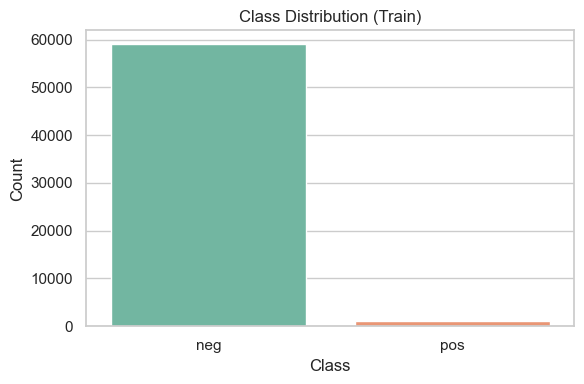

In [7]:
fig, ax = plt.subplots(figsize=(6, 4))
sns.countplot(data=tr, x='class', order=['neg', 'pos'], ax=ax, palette='Set2')
ax.set_title('Class Distribution (Train)')
ax.set_xlabel('Class')
ax.set_ylabel('Count')
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_28428\3266576191.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=miss_top, y='feature', x='missing_pct', ax=ax, palette='viridis')


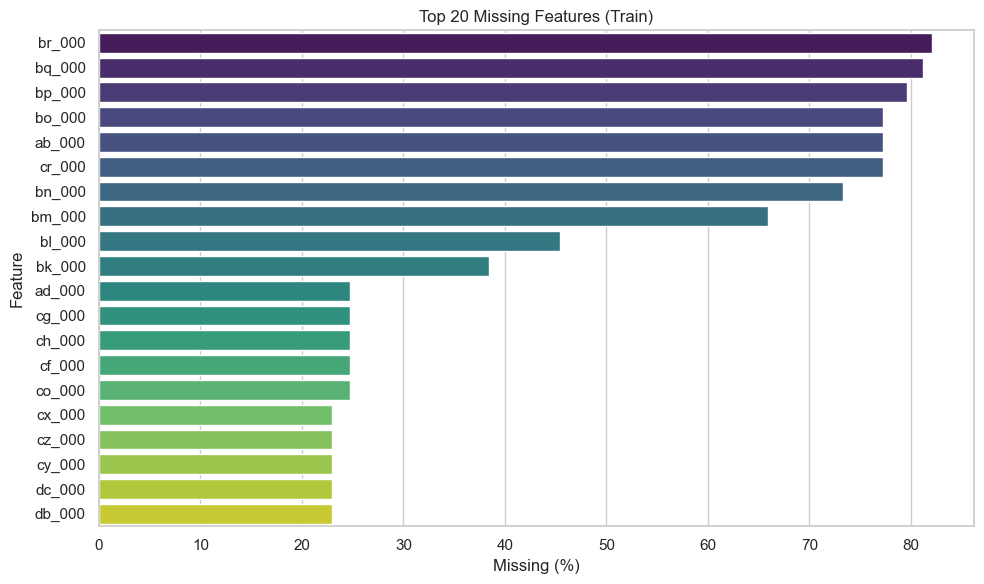

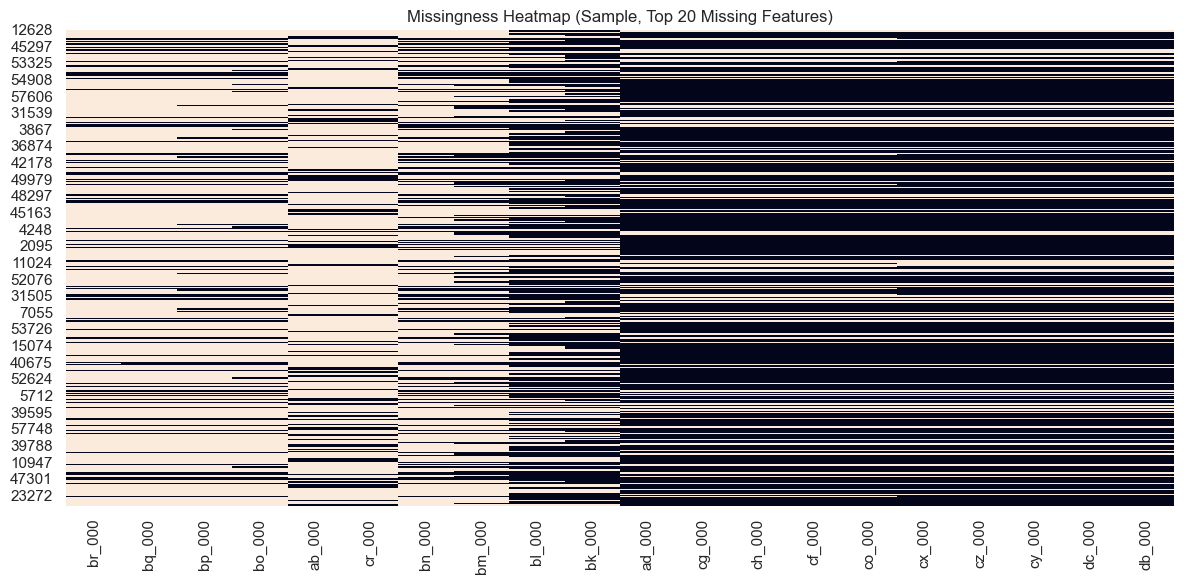

In [8]:
miss_top = (miss.head(20) * 100).reset_index()
miss_top.columns = ['feature', 'missing_pct']

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=miss_top, y='feature', x='missing_pct', ax=ax, palette='viridis')
ax.set_title('Top 20 Missing Features (Train)')
ax.set_xlabel('Missing (%)')
ax.set_ylabel('Feature')
plt.tight_layout()
plt.show()

cols = miss.head(20).index.tolist()
samp = tr[cols].isna().sample(n=min(400, len(tr)), random_state=42)

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(samp, cbar=False, ax=ax)
ax.set_title('Missingness Heatmap (Sample, Top 20 Missing Features)')
plt.tight_layout()
plt.show()


In [9]:
num = tr.drop(columns=['class']).apply(pd.to_numeric, errors='coerce')

ok = num.columns[num.isna().mean() < 0.2]
num_ok = num[ok].copy()

mid = num_ok.median()
num_ok = num_ok.fillna(mid)

y = (tr['class'] == 'pos').astype(int)

m0 = num_ok[y == 0].mean()
m1 = num_ok[y == 1].mean()

diff = (m1 - m0).abs().sort_values(ascending=False)
top = diff.head(8).index.tolist()

print('selected features for class-wise plots:')
print(top)


selected features for class-wise plots:
['ac_000', 'dq_000', 'eb_000', 'bb_000', 'bv_000', 'bu_000', 'cq_000', 'bx_000']


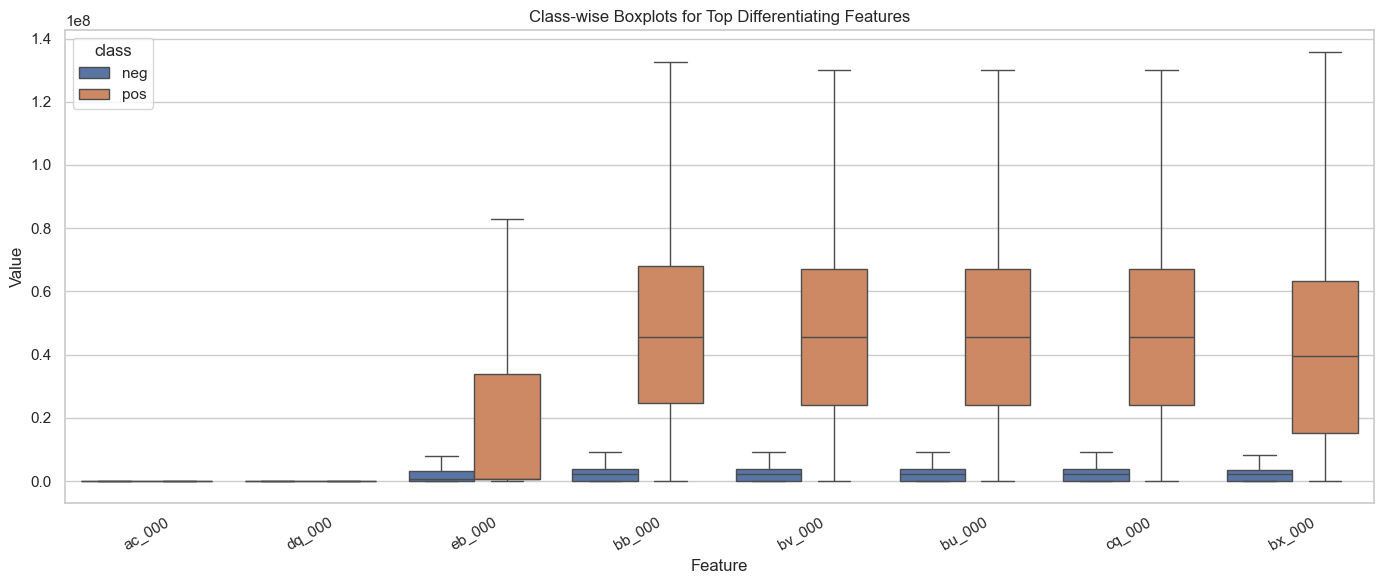

In [10]:
plot_df = tr[['class'] + top].copy()

for c in top:
    plot_df[c] = pd.to_numeric(plot_df[c], errors='coerce')
    plot_df[c] = plot_df[c].fillna(plot_df[c].median())

long_df = plot_df.melt(id_vars='class', var_name='feature', value_name='value')

fig, ax = plt.subplots(figsize=(14, 6))
sns.boxplot(data=long_df, x='feature', y='value', hue='class', ax=ax, showfliers=False)
ax.set_title('Class-wise Boxplots for Top Differentiating Features')
ax.set_xlabel('Feature')
ax.set_ylabel('Value')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()


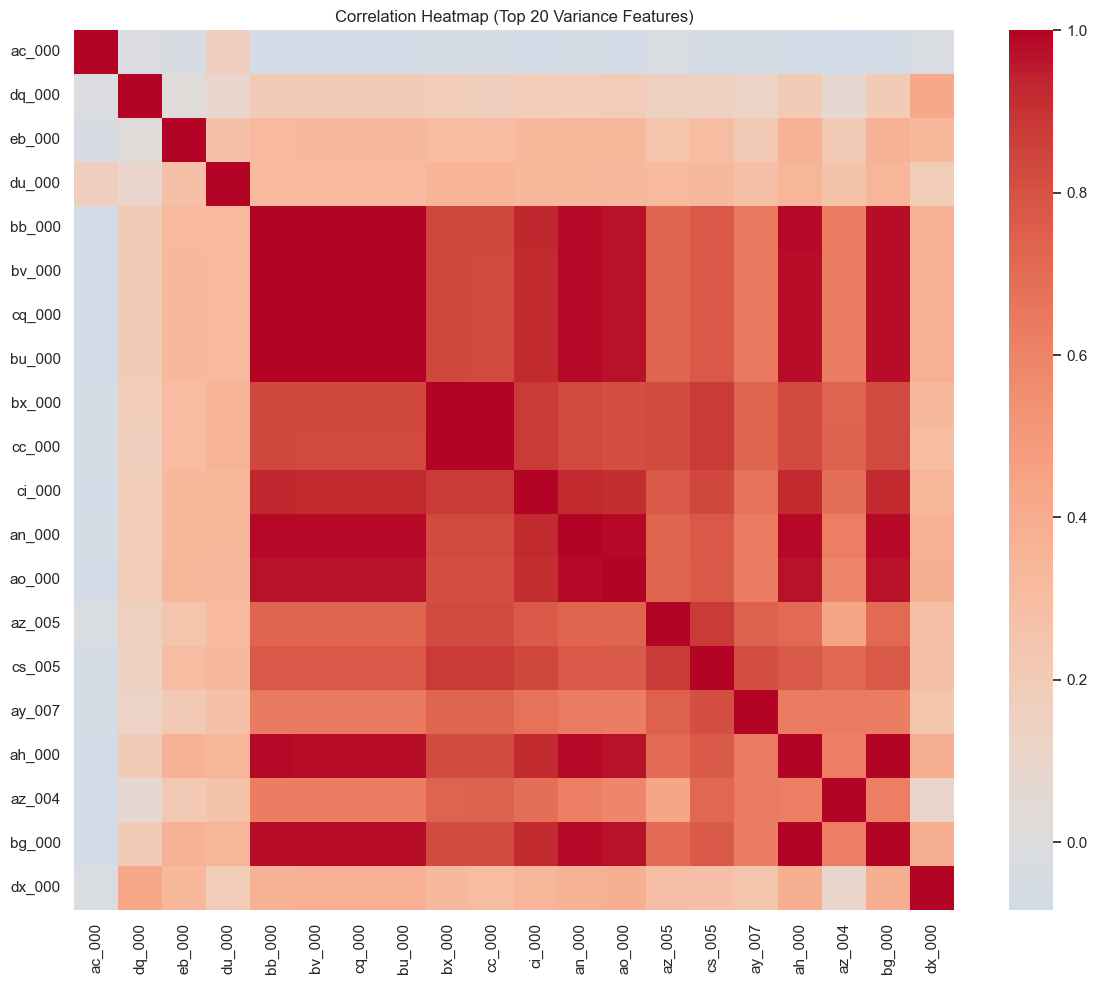

In [11]:
var = num_ok.var().sort_values(ascending=False)
cor_cols = var.head(20).index.tolist()
cor = num_ok[cor_cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(cor, cmap='coolwarm', center=0, ax=ax)
ax.set_title('Correlation Heatmap (Top 20 Variance Features)')
plt.tight_layout()
plt.show()


C:\Users\user\AppData\Local\Temp\ipykernel_28428\3699349709.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  sub = pair_df.groupby('class', group_keys=False).apply(


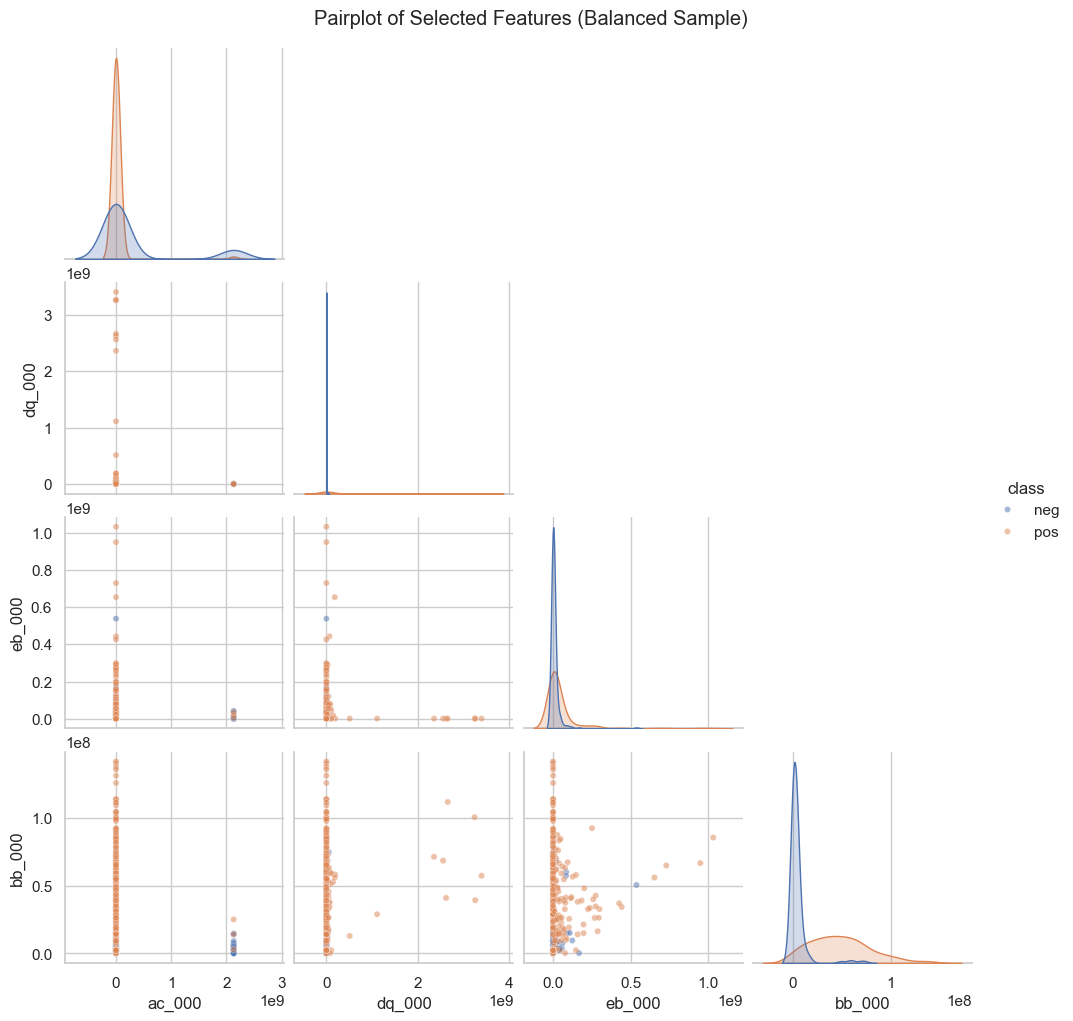

In [12]:
pair_cols = top[:4]
pair_df = tr[['class'] + pair_cols].copy()
for c in pair_cols:
    pair_df[c] = pd.to_numeric(pair_df[c], errors='coerce').fillna(pair_df[c].median())

sub = pair_df.groupby('class', group_keys=False).apply(
    lambda d: d.sample(n=min(250, len(d)), random_state=42)
).reset_index(drop=True)

sns.pairplot(sub, vars=pair_cols, hue='class', corner=True, plot_kws={'alpha': 0.5, 's': 20})
plt.suptitle('Pairplot of Selected Features (Balanced Sample)', y=1.02)
plt.show()


In [17]:
save_figs = True

if save_figs:
    fig_dir.mkdir(parents=True, exist_ok=True)

    plots = [
        ('class_dist.png', 'Class Distribution'),
        ('missing_top20.png', 'Top Missing Features'),
        ('missing_heatmap.png', 'Missingness Heatmap'),
        ('class_boxplots_top_features.png', 'Class-wise Boxplots'),
        ('corr_top20.png', 'Correlation Heatmap'),
    ]

    print('Set save_figs=True and rerun cells to save figures under thesis_doc/figures.')
else:
    print('Figure export is disabled. Set save_figs=True if you want thesis-ready image files.')


Set save_figs=True and rerun cells to save figures under thesis_doc/figures.
